# Notebook 13 — Student (2.5D) Explainability

Hafif deployment modeli (student_2p5d, det 0.997 / mal 0.986 / Dice 0.859) de **açıklanabilir**.
Student da saf CBM: `malignancy = Linear(8 concept → 2)`. Yeniden eğitim YOK.

NB10 ile aynı analizler, 2.5D'ye uyarlanmış (girdi 7 eksenel dilim): concept katkı, intervention, saliency, multi-task görsel, test seti özeti.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os, gc
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import h5py
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

Mounted at /content/drive
device: cuda


## 2. Config

In [2]:
BASE='/content/drive/MyDrive/bitirme'
CHECKPOINTS_DIR=f'{BASE}/Checkpoints_Advanced'
TEST_H5=f'{BASE}/Finetune_Patches/patches_test.h5'
# Student checkpoint: önce local güvence, yoksa Drive
STUDENT_LOCAL='/content/student_2p5d_best_GUVENCE.pth'
STUDENT_DRIVE=f'{CHECKPOINTS_DIR}/student_2p5d_best.pth'

ROI=64; N_SLICES=7; N_CONCEPTS=8
HU_CLIP=(-1000,1000)
CONCEPT_NAMES=['subtlety','internalStructure','calcification','sphericity',
               'margin','lobulation','spiculation','texture']
print('Config OK')

Config OK


## 3. Student mimarisi (2.5D, NB12 ile aynı)

In [3]:
class ResBlock2D(nn.Module):
    def __init__(self,i,o):
        super().__init__()
        self.conv1=nn.Conv2d(i,o,3,padding=1,bias=False); self.norm1=nn.InstanceNorm2d(o)
        self.conv2=nn.Conv2d(o,o,3,padding=1,bias=False); self.norm2=nn.InstanceNorm2d(o)
        self.act=nn.LeakyReLU(0.1,inplace=True); self.skip=nn.Conv2d(i,o,1,bias=False) if i!=o else nn.Identity()
    def forward(self,x):
        idt=self.skip(x); out=self.act(self.norm1(self.conv1(x))); out=self.norm2(self.conv2(out)); return self.act(out+idt)
class UNet2D(nn.Module):
    def __init__(self,in_channels,base=24):
        super().__init__()
        self.stem=ResBlock2D(in_channels,base)
        self.down1=nn.Sequential(nn.MaxPool2d(2),ResBlock2D(base,base*2))
        self.down2=nn.Sequential(nn.MaxPool2d(2),ResBlock2D(base*2,base*4))
        self.down3=nn.Sequential(nn.MaxPool2d(2),ResBlock2D(base*4,base*8))
        self.bottom=nn.Sequential(nn.MaxPool2d(2),ResBlock2D(base*8,base*16))
        self.global_pool=nn.AdaptiveAvgPool2d(1)
        self.up4=nn.ConvTranspose2d(base*16,base*8,2,2); self.dec4=ResBlock2D(base*16,base*8)
        self.up3=nn.ConvTranspose2d(base*8,base*4,2,2);  self.dec3=ResBlock2D(base*8,base*4)
        self.up2=nn.ConvTranspose2d(base*4,base*2,2,2);  self.dec2=ResBlock2D(base*4,base*2)
        self.up1=nn.ConvTranspose2d(base*2,base,2,2);    self.dec1=ResBlock2D(base*2,base)
        self.final=nn.Conv2d(base,1,1); self.out_dim=base*16
    def forward(self,x):
        s0=self.stem(x); s1=self.down1(s0); s2=self.down2(s1); s3=self.down3(s2); b=self.bottom(s3)
        gf=self.global_pool(b).flatten(1)
        u4=self.up4(b); d4=self.dec4(torch.cat([u4,s3],1)); u3=self.up3(d4); d3=self.dec3(torch.cat([u3,s2],1))
        u2=self.up2(d3); d2=self.dec2(torch.cat([u2,s1],1)); u1=self.up1(d2); d1=self.dec1(torch.cat([u1,s0],1))
        return gf, self.final(d1)
class Student2p5D(nn.Module):
    def __init__(self,n_slices=7,n_concepts=8,head_dropout=0.1):
        super().__init__()
        self.cnn=UNet2D(n_slices,base=24); cd=self.cnn.out_dim
        self.detection_head=nn.Sequential(nn.LayerNorm(cd),nn.Linear(cd,256),nn.GELU(),nn.Dropout(head_dropout),nn.Linear(256,2))
        self.concept_head=nn.Sequential(nn.LayerNorm(cd),nn.Linear(cd,256),nn.GELU(),nn.Dropout(0.3),nn.Linear(256,n_concepts))
        self.malignancy_head=nn.Linear(n_concepts,2)
    def forward(self,x):
        gf,seg=self.cnn(x); c=self.concept_head(gf)
        return {'detection':self.detection_head(gf),'concepts':c,'malignancy':self.malignancy_head(c),'segmentation':seg}
print('Student mimari OK')

Student mimari OK


## 4. Student checkpoint yükle

In [4]:
student=Student2p5D(N_SLICES,N_CONCEPTS).to(device)
path = STUDENT_LOCAL if os.path.exists(STUDENT_LOCAL) else STUDENT_DRIVE
ck=torch.load(path,map_location=device,weights_only=False)
sd=ck['model_state_dict'] if 'model_state_dict' in ck else ck
mi,un=student.load_state_dict(sd,strict=False)
student.eval()
print('Yüklendi:',path)
print('  eksik',len(mi),'beklenmedik',len(un))

Yüklendi: /content/drive/MyDrive/bitirme/Checkpoints_Advanced/student_2p5d_best.pth
  eksik 0 beklenmedik 0


## 5. Global concept önemi (student malignancy_head)

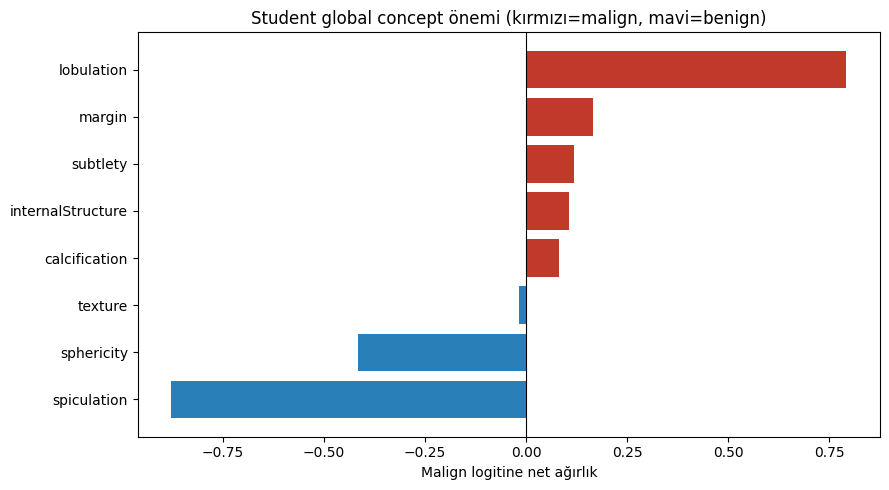

  lobulation        : +0.793
  margin            : +0.166
  subtlety          : +0.118
  internalStructure : +0.107
  calcification     : +0.082
  texture           : -0.018
  sphericity        : -0.416
  spiculation       : -0.878


In [5]:
W=student.malignancy_head.weight.detach().cpu().numpy(); w_net=W[1]-W[0]
order=np.argsort(w_net)
fig,ax=plt.subplots(figsize=(9,5))
colors=['#c0392b' if w_net[i]>0 else '#2980b9' for i in order]
ax.barh([CONCEPT_NAMES[i] for i in order],[w_net[i] for i in order],color=colors)
ax.axvline(0,color='k',lw=0.8); ax.set_xlabel('Malign logitine net ağırlık')
ax.set_title('Student global concept önemi (kırmızı=malign, mavi=benign)')
plt.tight_layout(); plt.savefig('/content/student_concept_importance.png',dpi=120); plt.show()
for i in order[::-1]: print(f'  {CONCEPT_NAMES[i]:18s}: {w_net[i]:+.3f}')

## 6. Test verisi + 2.5D dilim hazırlama

In [6]:
with h5py.File(TEST_H5,'r') as h5:
    patches_all=h5['patches'][:]; masks_all=h5['masks'][:]
    mal_all=h5['malignancy'][:]
print('Test patch:', patches_all.shape)
labeled=np.where(mal_all!=-1)[0]
print(f'Etiketli: {len(labeled)} (malign {int((mal_all[labeled]==1).sum())}, benign {int((mal_all[labeled]==0).sum())})')

def prep_slices(idx):
    """3D patch'ten ortadaki N_SLICES eksenel dilimi al → (1,N_SLICES,64,64)."""
    p=np.clip(patches_all[idx].astype(np.float32),HU_CLIP[0],HU_CLIP[1]); p=(p-HU_CLIP[0])/(HU_CLIP[1]-HU_CLIP[0])
    c=ROI//2; h=N_SLICES//2
    sl=p[c-h:c+h+1]
    return torch.from_numpy(sl[None]).to(device)
malign_idx=labeled[mal_all[labeled]==1]; benign_idx=labeled[mal_all[labeled]==0]

Test patch: (1130, 64, 64, 64)
Etiketli: 81 (malign 34, benign 47)


## 7. Tek vaka concept katkı analizi

=== MALIGN ===


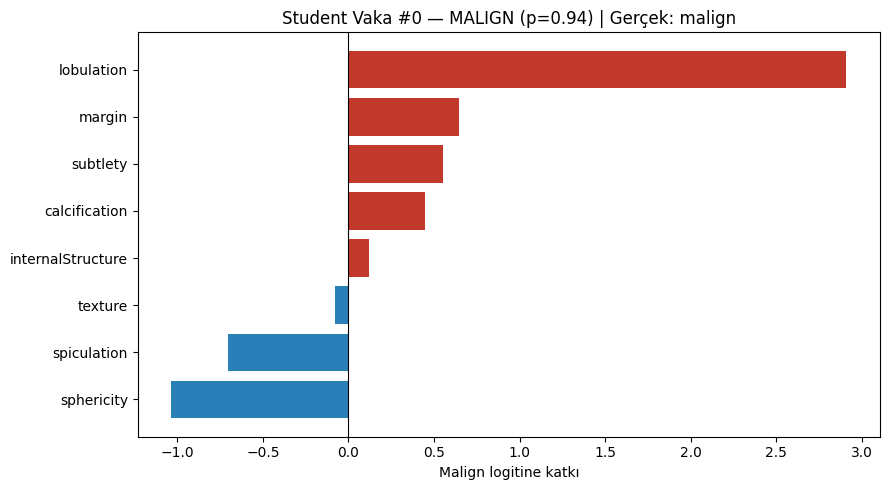

  lobulation        : pred=+3.67 katkı=+2.910
  margin            : pred=+3.90 katkı=+0.649
  subtlety          : pred=+4.69 katkı=+0.554
  calcification     : pred=+5.47 katkı=+0.449
  internalStructure : pred=+1.14 katkı=+0.122
  texture           : pred=+4.34 katkı=-0.079
  spiculation       : pred=+0.80 katkı=-0.702
  sphericity        : pred=+2.48 katkı=-1.034

=== BENIGN ===


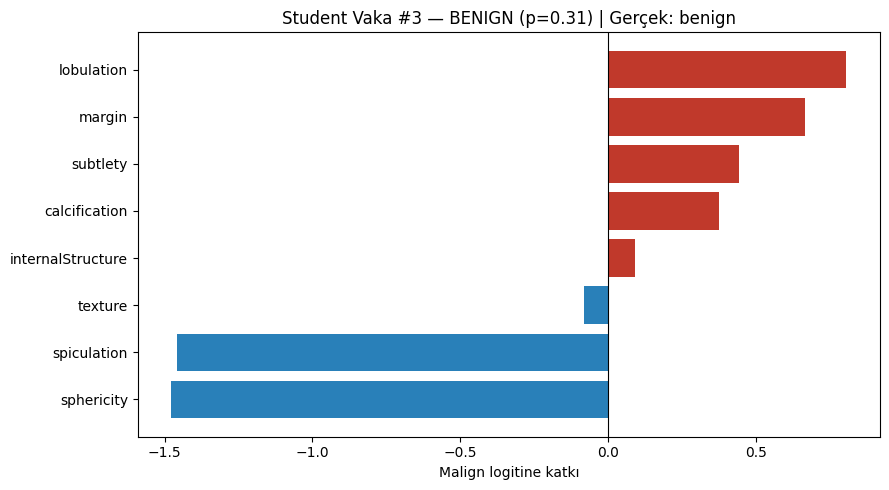

  lobulation        : pred=+1.02 katkı=+0.806
  margin            : pred=+4.00 katkı=+0.665
  subtlety          : pred=+3.74 katkı=+0.442
  calcification     : pred=+4.58 katkı=+0.376
  internalStructure : pred=+0.86 katkı=+0.092
  texture           : pred=+4.51 katkı=-0.082
  spiculation       : pred=+1.66 katkı=-1.460
  sphericity        : pred=+3.55 katkı=-1.477


(0.30780571699142456,
 array([ 0.44187623,  0.09156565,  0.37595785, -1.4770662 ,  0.66499674,
         0.80561095, -1.4595149 , -0.08218354], dtype=float32))

In [7]:
def explain_case(idx, show=True):
    with torch.no_grad(): out=student(prep_slices(idx))
    cp=out['concepts'][0].cpu().numpy(); mal_prob=torch.softmax(out['malignancy'][0],0)[1].item()
    contrib=w_net*cp; pred='MALIGN' if mal_prob>0.5 else 'BENIGN'; gt='malign' if mal_all[idx]==1 else 'benign'
    if show:
        o=np.argsort(contrib); fig,ax=plt.subplots(figsize=(9,5))
        colors=['#c0392b' if contrib[i]>0 else '#2980b9' for i in o]
        ax.barh([CONCEPT_NAMES[i] for i in o],[contrib[i] for i in o],color=colors)
        ax.axvline(0,color='k',lw=0.8); ax.set_xlabel('Malign logitine katkı')
        ax.set_title(f'Student Vaka #{idx} — {pred} (p={mal_prob:.2f}) | Gerçek: {gt}')
        plt.tight_layout(); plt.show()
        for i in np.argsort(contrib)[::-1]: print(f'  {CONCEPT_NAMES[i]:18s}: pred={cp[i]:+.2f} katkı={contrib[i]:+.3f}')
    return mal_prob, contrib
print('=== MALIGN ==='); explain_case(int(malign_idx[0]))
print('\n=== BENIGN ==='); explain_case(int(benign_idx[0]))

## 8. Concept intervention

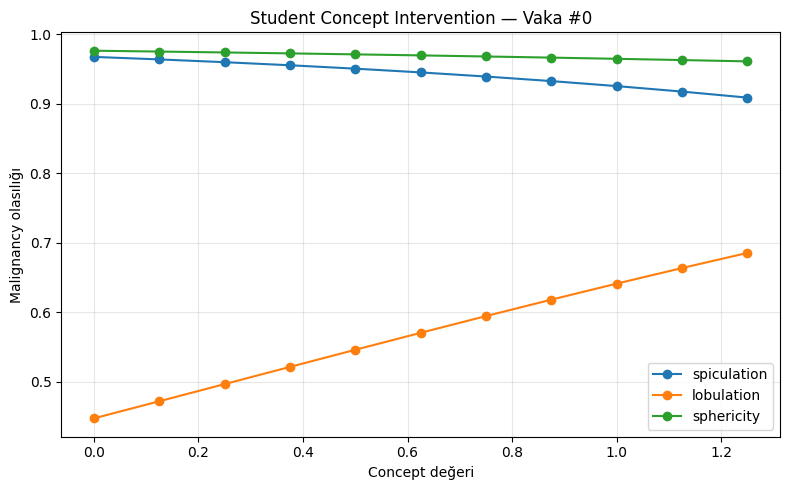

In [8]:
def intervene(idx,ci,sweep):
    with torch.no_grad(): out=student(prep_slices(idx))
    base=out['concepts'][0].clone(); probs=[]
    for v in sweep:
        c=base.clone(); c[ci]=float(v)
        probs.append(torch.softmax(student.malignancy_head(c.unsqueeze(0)),1)[0,1].item())
    return np.array(probs)
case=int(malign_idx[0]); top3=np.argsort(np.abs(w_net))[::-1][:3]; sweep=np.linspace(0,1.25,11)
fig,ax=plt.subplots(figsize=(8,5))
for ci in top3: ax.plot(sweep,intervene(case,ci,sweep),marker='o',label=CONCEPT_NAMES[ci])
ax.set_xlabel('Concept değeri'); ax.set_ylabel('Malignancy olasılığı')
ax.set_title(f'Student Concept Intervention — Vaka #{case}'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/content/student_intervention.png',dpi=120); plt.show()

## 9. Saliency (2.5D dilimler üzerinde)

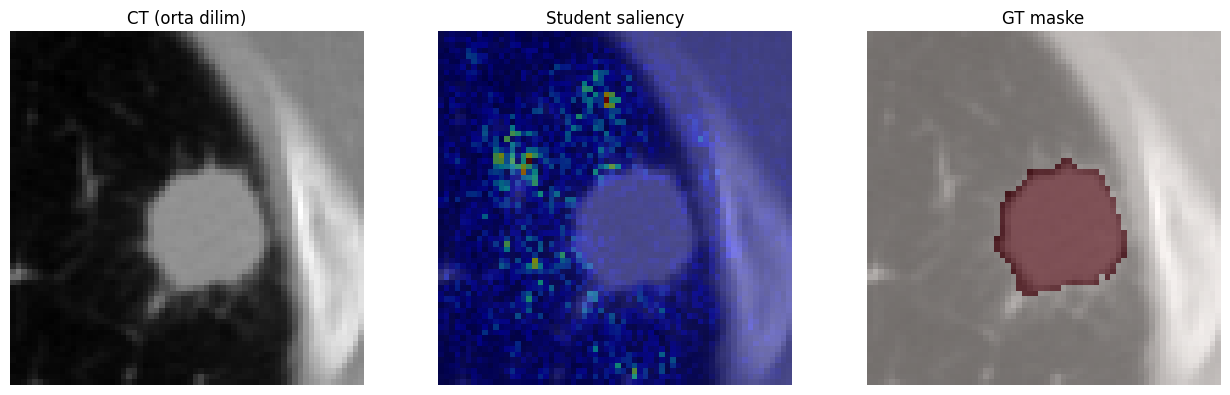

In [9]:
case=int(malign_idx[0])
x=prep_slices(case).clone().requires_grad_(True)
out=student(x); score=out['malignancy'][0,1]; student.zero_grad(); score.backward()
sal=x.grad[0].abs().cpu().numpy()   # (N_SLICES,64,64)
mid=N_SLICES//2
pn=np.clip(patches_all[case].astype(np.float32),HU_CLIP[0],HU_CLIP[1]); pn=(pn-HU_CLIP[0])/(HU_CLIP[1]-HU_CLIP[0])
z=ROI//2
fig,axes=plt.subplots(1,3,figsize=(13,4))
axes[0].imshow(pn[z],cmap='gray'); axes[0].set_title('CT (orta dilim)'); axes[0].axis('off')
axes[1].imshow(pn[z],cmap='gray'); axes[1].imshow(sal[mid],cmap='jet',alpha=0.5)
axes[1].set_title('Student saliency'); axes[1].axis('off')
axes[2].imshow(pn[z],cmap='gray')
if masks_all[case].sum()>0: axes[2].imshow(masks_all[case][z],cmap='Reds',alpha=0.45)
axes[2].set_title('GT maske'); axes[2].axis('off')
plt.tight_layout(); plt.savefig('/content/student_saliency.png',dpi=120); plt.show()

## 10. Multi-task görsel (student segmentasyonu orta dilim)

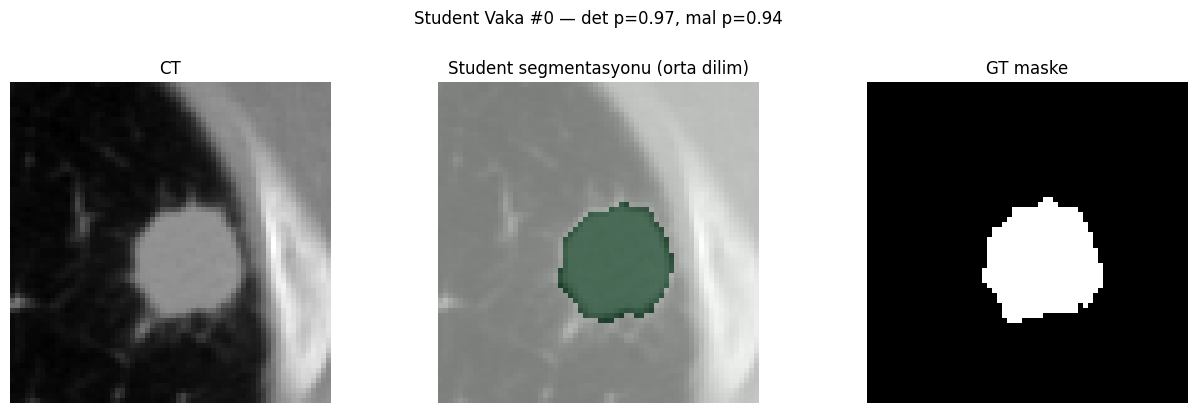

In [10]:
case=int(malign_idx[0])
with torch.no_grad(): out=student(prep_slices(case))
seg=torch.sigmoid(out['segmentation'][0,0]).cpu().numpy()
det_p=torch.softmax(out['detection'][0],0)[1].item(); mal_p=torch.softmax(out['malignancy'][0],0)[1].item()
pn=np.clip(patches_all[case].astype(np.float32),HU_CLIP[0],HU_CLIP[1]); pn=(pn-HU_CLIP[0])/(HU_CLIP[1]-HU_CLIP[0])
z=ROI//2
fig,axes=plt.subplots(1,3,figsize=(13,4))
axes[0].imshow(pn[z],cmap='gray'); axes[0].set_title('CT'); axes[0].axis('off')
axes[1].imshow(pn[z],cmap='gray'); axes[1].imshow(seg>0.5,cmap='Greens',alpha=0.5)
axes[1].set_title('Student segmentasyonu (orta dilim)'); axes[1].axis('off')
axes[2].imshow(masks_all[case][z],cmap='gray'); axes[2].set_title('GT maske'); axes[2].axis('off')
plt.suptitle(f'Student Vaka #{case} — det p={det_p:.2f}, mal p={mal_p:.2f}',y=1.02)
plt.tight_layout(); plt.savefig('/content/student_multitask.png',dpi=120); plt.show()

## 11. Tüm test seti — ortalama concept katkıları + teacher karşılaştırma notu

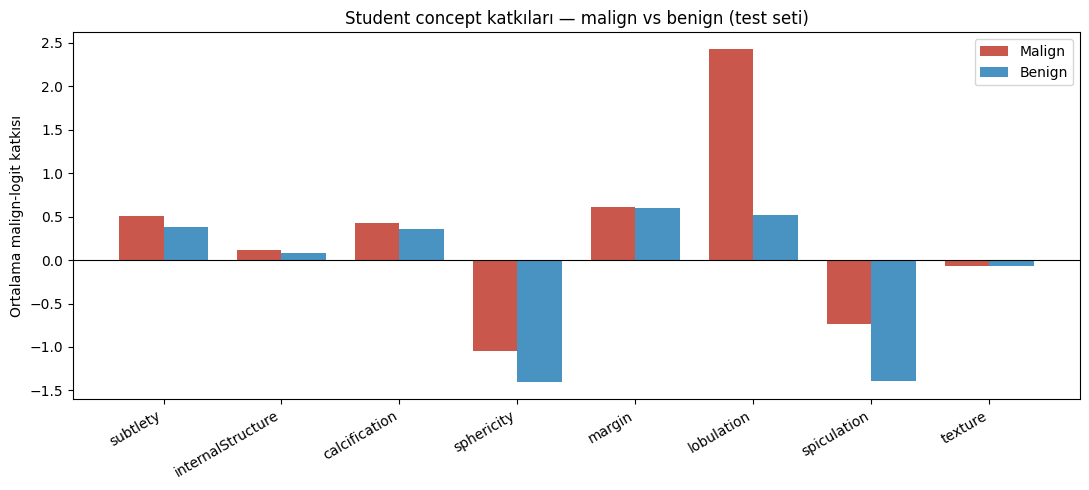

Student malign vakalarda en baskın concept'ler:
  lobulation        : +2.426
  margin            : +0.607
  subtlety          : +0.504
  calcification     : +0.430

Not: Student'ın concept önem sıralaması teacher (NB10) ile karşılaştırılabilir —
     aynı klinik örüntü (spiculation/lobulation malign) korunmuşsa distillation açıklanabilirliği de taşımış demektir.


In [11]:
mal_c,ben_c=[],[]
for idx in labeled:
    _,contrib=explain_case(int(idx),show=False)
    (mal_c if mal_all[idx]==1 else ben_c).append(contrib)
mal_c=np.array(mal_c); ben_c=np.array(ben_c)
x=np.arange(N_CONCEPTS); w=0.38
fig,ax=plt.subplots(figsize=(11,5))
ax.bar(x-w/2,mal_c.mean(0),w,label='Malign',color='#c0392b',alpha=0.85)
ax.bar(x+w/2,ben_c.mean(0),w,label='Benign',color='#2980b9',alpha=0.85)
ax.axhline(0,color='k',lw=0.8); ax.set_xticks(x); ax.set_xticklabels(CONCEPT_NAMES,rotation=30,ha='right')
ax.set_ylabel('Ortalama malign-logit katkısı')
ax.set_title('Student concept katkıları — malign vs benign (test seti)')
ax.legend(); plt.tight_layout(); plt.savefig('/content/student_concept_summary.png',dpi=120); plt.show()
print('Student malign vakalarda en baskın concept\'ler:')
for i in np.argsort(mal_c.mean(0))[::-1][:4]: print(f'  {CONCEPT_NAMES[i]:18s}: {mal_c.mean(0)[i]:+.3f}')
print('\nNot: Student\'ın concept önem sıralaması teacher (NB10) ile karşılaştırılabilir —')
print('     aynı klinik örüntü (spiculation/lobulation malign) korunmuşsa distillation açıklanabilirliği de taşımış demektir.')